MODULE 1: NUMPY

In [1]:
import numpy as np
from src.data_processing import q1_load_data, q2_statistics, q3_normalization, q10_batch_processing

In [2]:
#Q1. Load the dataset into a NumPy array using only the numerical features (e.g., Age,RestingBP, Cholesterol, MaxHR, Oldpeak). Check the shape and data type (dtype) of the array
data_arr, shape, dtype = q1_load_data('../data/raw/heart.csv')
print(f"Shape: {shape}")
print(f"Data Type: {dtype}")

Shape: (918, 5)
Data Type: float64


In [3]:
#Q2. Calculate the Mean, Median, and Standard Deviation for the Age, RestingBP, and Cholesterol columns using NumPy functions
means, medians, stds = q2_statistics(data_arr)
print("Age, RestingBP and Cholesterol")
print(f"Mean: {means}")
print(f"Median: {medians}")
print(f"Std Dev: {stds}")

Age, RestingBP and Cholesterol
Mean: [ 53.51089325 132.39651416 198.79956427]
Median: [ 54. 130. 223.]
Std Dev: [  9.42747752  18.50406741 109.3245509 ]


In [4]:
#Q3. Apply Min-Max normalization to scale all numerical features to the range [0, 1] using vectorized operations.
data_norm = q3_normalization(data_arr)

In [5]:
#Q4. Use boolean indexing to filter out patients with Age > 50 and a Cholesterol index greater than the average of the entire dataset.
overall_avg = np.mean(data_arr[:, 2])
mask = (data_arr[:, 0] > 50) & (data_arr[:, 2] > overall_avg)
filtered_data = data_arr[mask]
print(f"Age>50 and Chol > Average: {len(filtered_data)}")

Age>50 and Chol > Average: 381


In [6]:
#Q5. Calculate the correlation matrix between the numerical features entirely with NumPy (without using Pandas)
corr_matrix = np.corrcoef(data_arr, rowvar=False)

feature_names = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print(f"{'':15}" + "".join([f"{name:>12}" for name in feature_names]))
for i, name in enumerate(feature_names):
    row_values = "".join([f"{val:12.4f}" for val in corr_matrix[i]])
    print(f"{name:15}{row_values}")

                        Age   RestingBP Cholesterol       MaxHR     Oldpeak
Age                  1.0000      0.2544     -0.0953     -0.3820      0.2586
RestingBP            0.2544      1.0000      0.1009     -0.1121      0.1648
Cholesterol         -0.0953      0.1009      1.0000      0.2358      0.0501
MaxHR               -0.3820     -0.1121      0.2358      1.0000     -0.1607
Oldpeak              0.2586      0.1648      0.0501     -0.1607      1.0000


In [7]:
#Q6.: Write a fully vectorized function to calculate the Euclidean distance between patients using only numerical features (avoiding standard Python loops)
diff = data_arr[:, np.newaxis, :] - data_arr[np.newaxis, :, :] # Hiệu số giữa từng cặp
squared_diff = diff ** 2                                       # Bình phương hiệu số
sum_squared_diff = np.sum(squared_diff, axis=-1)               # Tổng bình phương theo các cột thuộc tính
euclidean_dist_matrix = np.sqrt(sum_squared_diff)              # Căn bậc hai

#Kích thước ma trận khoảng cách Euclidean giữa các cặp bệnh nhân:
print(euclidean_dist_matrix.shape)
#Ví dụ khoảng cách giữa bệnh nhân 0 và bệnh nhân 1:
print(euclidean_dist_matrix[0, 1])

(918, 918)
112.33432244866215


Min-Max: $X_{new} = \frac{X - X_{min}}{X_{max} - X_{min}}$

Z-score: $X_{new} = \frac{X - \mu}{\sigma}$

In [8]:
#Q7. Implement from scratch both Min-Max and Z-score normalization methods using NumPy and compare their results.
# 1. Min-Max Normalization
x_min = np.min(data_arr, axis=0)
x_max = np.max(data_arr, axis=0)
data_min_max = (data_arr - x_min) / (x_max - x_min)
# 2. Z-score Normalization
x_mean = np.mean(data_arr, axis=0)
x_std = np.std(data_arr, axis=0)
data_z_score = (data_arr - x_mean) / x_std

#So sánh kết quả chuẩn hóa của bệnh nhân đầu tiên:
print("Raw: ", data_arr[0])
print("After Min-Max: ", data_min_max[0])
print("After Z-score: ", data_z_score[0])

Raw:  [ 40. 140. 289. 172.   0.]
After Min-Max:  [0.24489796 0.7        0.47927032 0.78873239 0.29545455]
After Z-score:  [-1.4331398   0.41090889  0.82507026  1.38292822 -0.83243239]


In [9]:
#Q8. Calculate the Cosine similarity between two selected patient vectors from the dataset (using only numerical features).
#Tính Cosine similarity giữa bệnh nhân số 0 và bệnh nhân số 1
p0 = data_arr[0]
p1 = data_arr[1]

# Tính tích vô hướng (Dot product)
dot_product = np.dot(p0, p1)

# Tính độ dài (Norm) của từng vectơ
norm_p0 = np.linalg.norm(p0)
norm_p1 = np.linalg.norm(p1)

# Tính Cosine similarity
cosine_sim = dot_product / (norm_p0 * norm_p1)

print(f"{cosine_sim:.4f}")

0.9675


In [10]:
#Q9. Manually perform the PCA (Principal Component Analysis) algorithm using NumPy: construct the covariance matrix from the numerical variables, calculate the eigenvalues and eigenvectors, and then project the data onto the top 2 principal components.
#Trừ đi trung bình của mỗi cột (Mean-centering)
centered_data = data_arr - np.mean(data_arr, axis=0)

#Xây dựng ma trận hiệp phương sai (bắt buộc đặt rowvar=False)
cov_matrix = np.cov(centered_data, rowvar=False)

#ính trị riêng và vectơ riêng từ ma trận hiệp phương sai
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

#Sắp xếp các vectơ riêng dựa trên trị riêng giảm dần
sorted_indices = np.argsort(eigenvalues)[::-1] # Lấy chỉ số sắp xếp giảm dần
top_2_indices = sorted_indices[:2]             # Lấy 2 thành phần chính tốt nhất
pca_components = eigenvectors[:, top_2_indices] # Ma trận phép chiếu (kích thước 5x2)

#Chiếu dữ liệu ban đầu lên 2 thành phần chính mới
projected_data = np.dot(centered_data, pca_components) # Kết quả có kích thước (918, 2)

print("Kết quả thuật toán PCA")
print("Kích thước dữ liệu sau khi chiếu (PCA giảm chiều):", projected_data.shape)
print("Trị riêng của các thành phần:", eigenvalues[top_2_indices])
print("Tọa độ 2 chiều mới của bệnh nhân đầu tiên:", projected_data[0])

Kết quả thuật toán PCA
Kích thước dữ liệu sau khi chiếu (PCA giảm chiều): (918, 2)
Trị riêng của các thành phần: [12007.21677896   640.94447337]
Tọa độ 2 chiều mới của bệnh nhân đầu tiên: [ 92.31040518 -29.43582241]


In [11]:
#Q10. Implement batch processing by dividing a NumPy array into equally sized batches and calculating the mean vector for each batch.
batch_size = 30
n_samples = data_arr.shape[0]

#Tính toán số lượng lô đầy đủ. Vì 918 chia cho 30 dư 18, nên lấy các phần chia hết để đảm bảo "equally sized" (bằng nhau)
n_batches = n_samples // batch_size
truncated_data = data_arr[:n_batches * batch_size] # Cắt bỏ phần dư thừa để các mảng bằng nhau tuyệt đối

#Thay đổi kích thước (Reshape) mảng thành dạng: (Số lô, Kích thước lô, Số thuộc tính)
batched_data = truncated_data.reshape(n_batches, batch_size, data_arr.shape[1])

#Tính vectơ trung bình cho mỗi lô (Tính trung bình theo trục số 1 - trục chứa số lượng hàng của 1 lô)
batch_means = np.mean(batched_data, axis=1)

print(f"- Tổng số lô có kích thước bằng nhau ({batch_size} dòng/lô): {n_batches}")
print("- Kích thước ma trận kết quả (Số lô x Số thuộc tính trung bình):", batch_means.shape)
print("- Vectơ trung bình của lô đầu tiên (Batch 0):\n ", batch_means[0])

- Tổng số lô có kích thước bằng nhau (30 dòng/lô): 30
- Kích thước ma trận kết quả (Số lô x Số thuộc tính trung bình): (30, 5)
- Vectơ trung bình của lô đầu tiên (Batch 0):
  [ 45.73333333 126.16666667 238.83333333 141.1          0.65      ]


MODULE 2: MATHEMATICS FOR AI

In [12]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('../src'))
from utils import (calculate_probabilities, calculate_covariance_and_variance,
                   compute_covariance_eigen, perform_svd, calculate_bayes_age)
from modelling import LinearRegressionCustom

In [13]:
#Q1. Represent the dataset as a numerical matrix (using only numerical features) and determine the shape and rank of the matrix.
matrix_X = data_arr.copy()
matrix_shape = matrix_X.shape
matrix_rank = np.linalg.matrix_rank(matrix_X)
print(f"Kích thước ma trận: {matrix_shape} | Hạng (Rank) của ma trận: {matrix_rank}\n")

Kích thước ma trận: (918, 5) | Hạng (Rank) của ma trận: 5



In [14]:
#Q2. Using the target variable HeartDisease, apply Linear Regression using Age and MaxHR topredict heart disease based on the model:
target_y = np.genfromtxt('../data/raw/heart.csv', delimiter=',', skip_header=1, usecols=11)

X_q2 = data_arr[:, [0, 3]]
model_q2 = LinearRegressionCustom()
w_q2, b_q2 = model_q2.fit_analytic(X_q2, target_y)
print(f"Trọng số tối ưu giải tích: w = {w_q2}, Hệ số chặn b = {b_q2}\n")

Trọng số tối ưu giải tích: w = [ 0.00796889 -0.00669502], Hệ số chặn b = 1.0428961584802883



In [15]:
#Q3
sex_data = np.genfromtxt('../data/raw/heart.csv', delimiter=',', skip_header=1, usecols=1, dtype=str)

p_hd, p_hd_male = calculate_probabilities(data_arr, sex_data, target_y)
print(f"P(HeartDisease = 1) = {p_hd:.4f}")
print(f"P(HeartDisease = 1 | Sex = M) = {p_hd_male:.4f}\n")

P(HeartDisease = 1) = 0.5534
P(HeartDisease = 1 | Sex = M) = 0.6317



In [16]:
#Q4
dw, db, current_mse = LinearRegressionCustom.compute_gradient(X_q2, target_y, w_q2, b_q2)
print(f"Đạo hàm tổn thất tại nghiệm giải tích:")
print(f"Gradient dw = {dw}, db = {db} | MSE Loss = {current_mse:.6f}\n")

Đạo hàm tổn thất tại nghiệm giải tích:
Gradient dw = [3.21988865e-15 6.93514478e-15], db = 1.5286730970873616e-16 | MSE Loss = 0.202703



In [17]:
# Q5
# Vị trí Age=0, Cholesterol=2
var_chol, cov_chol_age = calculate_covariance_and_variance(data_arr, 2, 0)
print(f"Phương sai của Cholesterol = {var_chol:.4f}")
print(f"Hiệp phương sai giữa Cholesterol và Age = {cov_chol_age:.4f}\n")

Phương sai của Cholesterol = 11964.8911
Hiệp phương sai giữa Cholesterol và Age = -98.3097



In [18]:
#Q6
cov_mat, eigen_vals, eigen_vecs = compute_covariance_eigen(data_arr)
print("Ma trận hiệp phương sai kích thước:", cov_mat.shape)
print("Các trị riêng tương ứng (Eigenvalues):", eigen_vals)
print("Vectơ riêng (Eigenvectors) cột đầu tiên:\n", eigen_vecs[:, 0], "\n")

Ma trận hiệp phương sai kích thước: (5, 5)
Các trị riêng tương ứng (Eigenvalues): [1.20072168e+04 6.40944473e+02 3.27267008e+02 6.95401163e+01
 1.03704611e+00]
Vectơ riêng (Eigenvectors) cột đầu tiên:
 [-8.61336707e-03  1.71902740e-02  9.98149080e-01  5.76931516e-02
  4.68223356e-04] 



In [19]:
#Q7
U, S, VT = perform_svd(data_arr)
print(f"Kích thước ma trận U: {U.shape}, Sigma S: {S.shape}, V^T: {VT.shape}\n")

Kích thước ma trận U: (918, 5), Sigma S: (5,), V^T: (5, 5)



Iteration      0: Loss = 0.553377 | w1 (Age) = 0.000000 | w2 (MaxHR) = 0.000000 | b = 0.000000
Iteration   3000: Loss = 0.204966 | w1 (Age) = 0.559192 | w2 (MaxHR) = -0.676289 | b = 0.624876
Nghiệm tìm được bằng Gradient Descent: w = [ 0.55919167 -0.67628931], b = 0.6248755905204558


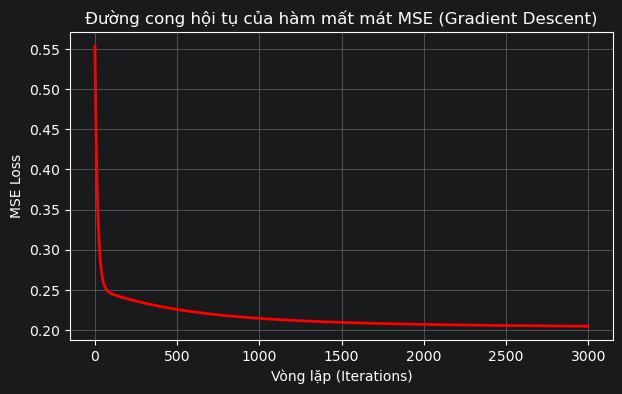


Đã lưu thành công đồ thị vào đường dẫn: ../outputs/figures/q8_loss_convergence.png


In [20]:
#Q8
model_gd = LinearRegressionCustom()

# Sử dụng mảng dữ liệu đã được Min-Max chuẩn hóa từ Câu Q3 Module 1
# Giả sử data_min_max là mảng đã chuẩn hóa của bạn
X_scaled = data_min_max[:, [0, 3]] # Lấy cột Age và MaxHR đã chuẩn hóa

w_gd, b_gd, loss_hist = model_gd.fit_gradient_descent(X_scaled, target_y, lr=0.01, iterations=3000)
print(f"Nghiệm tìm được bằng Gradient Descent: w = {w_gd}, b = {b_gd}")

# Vẽ đồ thị đường cong hội tụ (Loss convergence)
plt.figure(figsize=(7, 4))
plt.plot(loss_hist, color='red', lw=2)
plt.title("Đường cong hội tụ của hàm mất mát MSE (Gradient Descent)")
plt.xlabel("Vòng lặp (Iterations)")
plt.ylabel("MSE Loss")
plt.grid(True)

fig_path = os.path.join('../outputs/figures/', 'q8_loss_convergence.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()
print()



print(f"Đã lưu thành công đồ thị vào đường dẫn: {fig_path}")

In [21]:
#Q9
age_data = data_arr[:, 0]
age_bins, bayes_probs = calculate_bayes_age(age_data, target_y)
print(" Xác suất mắc bệnh tim theo nhóm tuổi dựa trên Định lý Bayes:")
for group, prob in bayes_probs.items():
    print(f"    P(HeartDisease = 1 | Nhóm tuổi = {group}) = {prob:.4f}\n")

 Xác suất mắc bệnh tim theo nhóm tuổi dựa trên Định lý Bayes:
    P(HeartDisease = 1 | Nhóm tuổi = Young) = 0.3250

    P(HeartDisease = 1 | Nhóm tuổi = Middle-aged) = 0.4514

    P(HeartDisease = 1 | Nhóm tuổi = Senior) = 0.7069



In [22]:
#Q10
model_ridge = LinearRegressionCustom()
w_ridge, b_ridge = model_ridge.fit_regularized(X_q2, target_y, alpha=10.0, method='ridge')

model_lasso = LinearRegressionCustom()
w_lasso, b_lasso = model_lasso.fit_regularized(X_q2, target_y, alpha=0.1, method='lasso')

print("So sánh tác động điều hòa lên các hệ số trọng số (w1_Age, w2_MaxHR):")
print(f"[Gốc giải tích]  w = {w_q2}")
print(f"[L2 Ridge Phạt]  w = {w_ridge}")
print(f"[L1 Lasso Phạt]  w = {w_lasso}")


So sánh tác động điều hòa lên các hệ số trọng số (w1_Age, w2_MaxHR):
[Gốc giải tích]  w = [ 0.00796889 -0.00669502]
[L2 Ridge Phạt]  w = [ 0.00796788 -0.00669505]
[L1 Lasso Phạt]  w = [ 0.01771603 -0.00296735]


MODULE 3: PANDAS

In [23]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khai báo cấu trúc thư mục nạp file logic từ src/
sys.path.append(os.path.abspath('../src'))
from data_processing import load_and_explore, clean_heart_data
from feature_engineering import (analyze_chest_pain, create_ratio_feature, create_pivot_ecg,
                                 bin_age_groups, bin_cholesterol_groups, perform_one_hot_encoding)

In [24]:
# Định nghĩa đường dẫn lưu file hình ảnh đồ thị đầu ra
fig_save_dir = '../outputs/figures/'
os.makedirs(fig_save_dir, exist_ok=True)

In [25]:
#Q1. Load the dataset into a Pandas DataFrame and display head(), info(), and describe() to explore the structure of the 12 attributes (comprising 918 rows)
df_raw = load_and_explore('../data/raw/heart.csv')

--- 5 Dòng đầu của dữ liệu (head) ---
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

--- Thông tin cấu trúc dữ liệu (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          

In [26]:
#Q2. Clean the data: handle invalid values (e.g., check for cases where Cholesterol or RestingBP vequals 0 and replace with NaN/Mean if necessary) and ensure the correct data type for all columns.
df_cleaned = clean_heart_data(df_raw)

Số hàng có RestingBP = 0: 1
Số hàng có Cholesterol = 0: 172
-> Đã làm sạch: Các giá trị lỗi bằng 0 đã được thay bằng giá trị trung bình tương ứng.


In [27]:
#Q3. Group the data (Groupby) by the ChestPainType variable and calculate the total number of patients as well as the Heart Disease rate for each group.
chest_pain_analysis = analyze_chest_pain(df_cleaned)
print("Thống kê tỷ lệ mắc bệnh theo Loại đau ngực:")
print(chest_pain_analysis.to_string(index=False))

Thống kê tỷ lệ mắc bệnh theo Loại đau ngực:
ChestPainType  Total_Patients  Heart_Disease_Rate
          ASY             496            0.790323
          ATA             173            0.138728
          NAP             203            0.354680
           TA              46            0.434783


In [28]:
#Q4. Create a new feature MaxHR_to_Age_Ratio = MaxHR / Age to analyze the level of exertionrelative to age.
df_features = create_ratio_feature(df_cleaned)
print("Đã thêm thuộc tính mới 'MaxHR_to_Age_Ratio'. Xem mẫu 3 dòng đầu:")
print(df_features[['Age', 'MaxHR', 'MaxHR_to_Age_Ratio']].head(3))

Đã thêm thuộc tính mới 'MaxHR_to_Age_Ratio'. Xem mẫu 3 dòng đầu:
   Age  MaxHR  MaxHR_to_Age_Ratio
0   40    172            4.300000
1   49    156            3.183673
2   37     98            2.648649


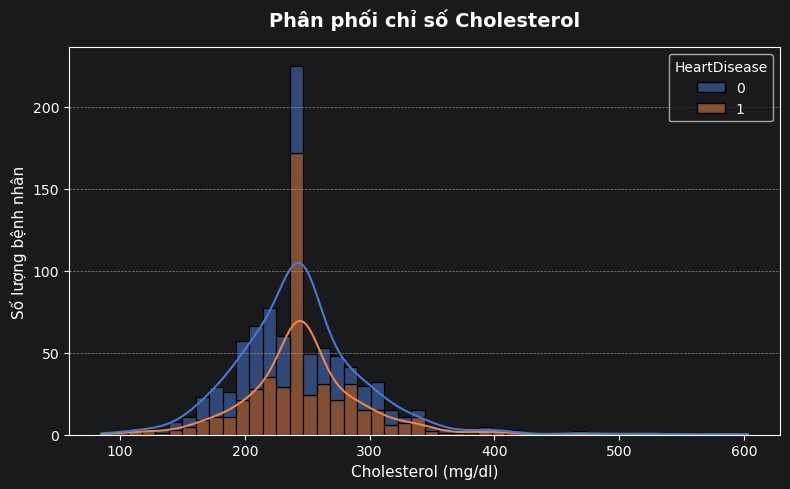

🌟 Đã lưu đồ thị phân phối Cholesterol vào: ../outputs/figures/q5_cholesterol_distribution.png


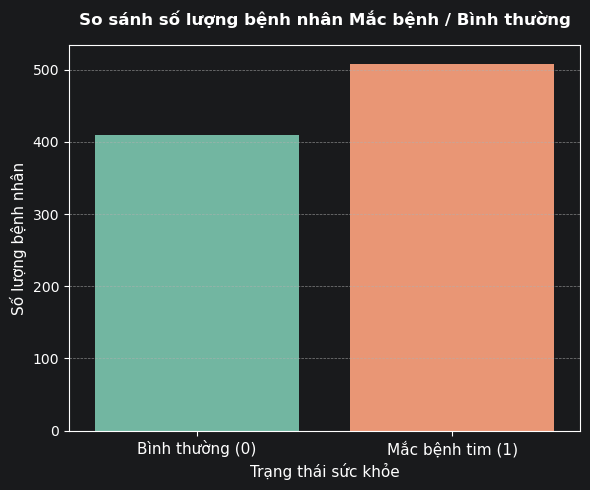

🌟 Đã lưu đồ thị đếm số lượng bệnh nhân vào: ../outputs/figures/q5_disease_patient_count.png


In [29]:
#Q5. Visualize the distribution of Cholesterol using a distribution plot (histogram) and compare the number of patients with/without heart disease using a bar chart.
# 1. Khởi tạo khung hình riêng cho đồ thị Cholesterol (kích thước lớn)
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ Histogram
sns.histplot(data=df_features, x='Cholesterol', hue='HeartDisease', kde=True, multiple='stack', palette='muted')

# Thiết lập tiêu đề và nhãn
plt.title("Phân phối chỉ số Cholesterol", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cholesterol (mg/dl)", fontsize=11)
plt.ylabel("Số lượng bệnh nhân", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tối ưu khoảng cách và Lưu file ảnh độc lập
plt.tight_layout()
fig_path_chol = os.path.join(fig_save_dir, 'q5_cholesterol_distribution.png')
plt.savefig(fig_path_chol, dpi=300, bbox_inches='tight')

# Hiển thị đồ thị
plt.show()
print(f"🌟 Đã lưu đồ thị phân phối Cholesterol vào: {fig_path_chol}")

# 2. Khởi tạo khung hình riêng cho đồ thị so sánh số lượng bệnh nhân
plt.figure(figsize=(6, 5))

# Vẽ biểu đồ thanh số lượng (Countplot)
sns.countplot(data=df_features, x='HeartDisease', hue='HeartDisease', palette='Set2', legend=False)

# Thiết lập tiêu đề và nhãn
plt.title("So sánh số lượng bệnh nhân Mắc bệnh / Bình thường", fontsize=12, fontweight='bold', pad=15)
plt.xticks([0, 1], ['Bình thường (0)', 'Mắc bệnh tim (1)'], fontsize=11)
plt.xlabel("Trạng thái sức khỏe", fontsize=11)
plt.ylabel("Số lượng bệnh nhân", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tối ưu khoảng cách và Lưu file ảnh độc lập
plt.tight_layout()
fig_path_count = os.path.join(fig_save_dir, 'q5_disease_patient_count.png')
plt.savefig(fig_path_count, dpi=300, bbox_inches='tight')

# Hiển thị đồ thị
plt.show()
print(f"🌟 Đã lưu đồ thị đếm số lượng bệnh nhân vào: {fig_path_count}")

In [30]:
#Q6. Create a pivot table with RestingECG as the index, HeartDisease as columns, and the count of patients as the values.
ecg_pivot = create_pivot_ecg(df_features)
print("Bảng xoay Pivot Table đếm bệnh nhân theo Kết quả điện tâm đồ (RestingECG):")
print(ecg_pivot)

Bảng xoay Pivot Table đếm bệnh nhân theo Kết quả điện tâm đồ (RestingECG):
HeartDisease    0    1
RestingECG            
LVH            82  106
Normal        267  285
ST             61  117


In [31]:
# --- Q7: Phân nhóm độ tuổi (Age Group) ---
df_features, age_analysis = bin_age_groups(df_features)
print("Phân tích tỷ lệ mắc bệnh tim theo các nhóm tuổi:")
print(age_analysis.to_string(index=False))

Phân tích tỷ lệ mắc bệnh tim theo các nhóm tuổi:
Age_Group  Total_Patients  Heart_Disease_Rate
      <40              80            0.325000
    40-55             432            0.451389
      55+             406            0.706897


In [32]:
# --- Q8: Phân nhóm chỉ số Cholesterol ---
df_features, chol_analysis = bin_cholesterol_groups(df_features)
print("\nQ8: Phân tích diễn tiến bệnh theo các phân khúc Cholesterol:")
print(chol_analysis.to_string(index=False))


Q8: Phân tích diễn tiến bệnh theo các phân khúc Cholesterol:
Cholesterol_Group  Total_Patients  Heart_Disease_Rate
           Normal             146            0.390411
       Borderline             237            0.455696
             High             535            0.641121


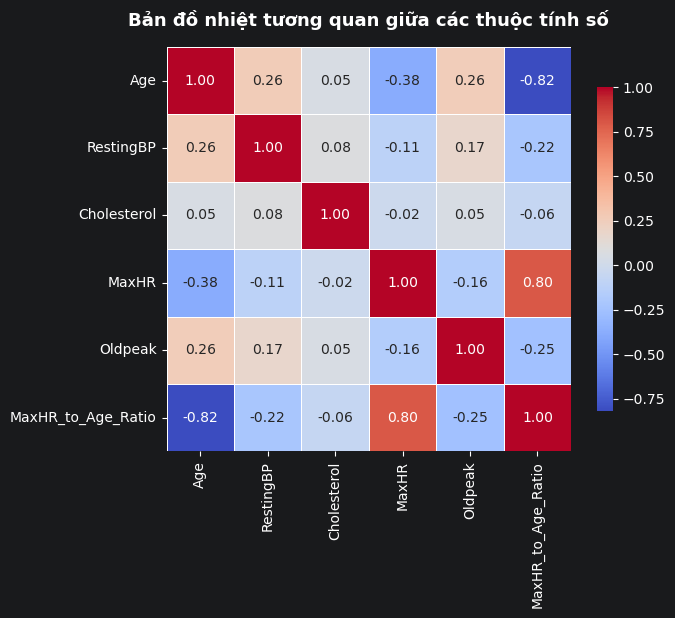

Đã lưu bản đồ nhiệt tương quan vào: ../outputs/figures/q9_correlation_heatmap.png


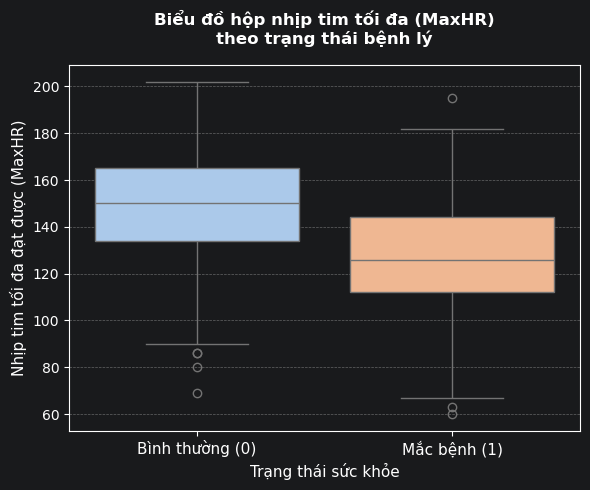

Đã lưu biểu đồ hộp MaxHR vào: ../outputs/figures/q9_maxhr_boxplot.png


In [33]:
# --- Q9: Trực quan hóa Nâng cao (Correlation Heatmap & Boxplot) ---
# 1. Khởi tạo khung hình vuông vắn lý tưởng cho ma trận Heatmap
plt.figure(figsize=(7, 6))

# Lọc các cột số và tính ma trận tương quan
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'MaxHR_to_Age_Ratio']
corr_matrix = df_features[numerical_cols].corr()

# Vẽ Heatmap (đặt cbar_kws để thanh màu không bị quá to)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})

# Thiết lập tiêu đề với font chữ chuyên nghiệp
plt.title("Bản đồ nhiệt tương quan giữa các thuộc tính số", fontsize=13, fontweight='bold', pad=15)

# Tối ưu khoảng cách và Lưu file ảnh riêng biệt
plt.tight_layout()
fig_path_heatmap = os.path.join(fig_save_dir, 'q9_correlation_heatmap.png')
plt.savefig(fig_path_heatmap, dpi=300, bbox_inches='tight')

# Hiển thị đồ thị
plt.show()
print(f"Đã lưu bản đồ nhiệt tương quan vào: {fig_path_heatmap}")

# 2. Khởi tạo khung hình đứng chuẩn mực cho biểu đồ Boxplot
plt.figure(figsize=(6, 5))

# Vẽ biểu đồ hộp (Boxplot)
sns.boxplot(data=df_features, x='HeartDisease', y='MaxHR', hue='HeartDisease', palette='pastel', legend=False)

# Thiết lập tiêu đề và nhãn trục rõ ràng
plt.title("Biểu đồ hộp nhịp tim tối đa (MaxHR)\ntheo trạng thái bệnh lý", fontsize=12, fontweight='bold', pad=15)
plt.xticks([0, 1], ['Bình thường (0)', 'Mắc bệnh (1)'], fontsize=11)
plt.xlabel("Trạng thái sức khỏe", fontsize=11)
plt.ylabel("Nhịp tim tối đa đạt được (MaxHR)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5) # Thêm lưới ngang để dễ đối chiếu khoảng tứ phân vị

# Tối ưu khoảng cách và Lưu file ảnh riêng biệt
plt.tight_layout()
fig_path_boxplot = os.path.join(fig_save_dir, 'q9_maxhr_boxplot.png')
plt.savefig(fig_path_boxplot, dpi=300, bbox_inches='tight')

# Hiển thị đồ thị
plt.show()
print(f"Đã lưu biểu đồ hộp MaxHR vào: {fig_path_boxplot}")

In [34]:
#Q10
df_final_clean = perform_one_hot_encoding(df_features)
print("\nQ10: Thực hiện Kỹ nghệ đặc trưng One-Hot Encoding hoàn tất.")
print(f"     Kích thước tập dữ liệu hoàn chỉnh, sẵn sàng đưa vào ML: {df_final_clean.shape}")
print("     Danh sách các cột đặc trưng mới sau khi xử lý mã hóa:")
print(list(df_final_clean.columns))

# Lưu tập dữ liệu đã xử lý sạch sẽ vào thư mục processed đúng kiến trúc dự án
processed_data_dir = '../data/processed/'
os.makedirs(processed_data_dir, exist_ok=True)
df_final_clean.to_csv(os.path.join(processed_data_dir, 'heart_cleaned_encoded.csv'), index=False)
print(f" Đã lưu tập dữ liệu cuối cùng vào: {processed_data_dir}heart_cleaned_encoded.csv")


Q10: Thực hiện Kỹ nghệ đặc trưng One-Hot Encoding hoàn tất.
     Kích thước tập dữ liệu hoàn chỉnh, sẵn sàng đưa vào ML: (918, 24)
     Danh sách các cột đặc trưng mới sau khi xử lý mã hóa:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'MaxHR_to_Age_Ratio', 'Age_Group', 'Cholesterol_Group', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
 Đã lưu tập dữ liệu cuối cùng vào: ../data/processed/heart_cleaned_encoded.csv
